In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [2]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data preprocessing

## Training image preprocessing

In [3]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'Train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)
##this is for image preprocessing , this was directly taken from keras library

Found 11108 files belonging to 6 classes.


In [4]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'Val',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 2495 files belonging to 6 classes.


## MODEL

In [5]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [6]:
model = Sequential()

In [7]:
##builiding convolution layer

In [8]:
model.add(Conv2D(filters=32,kernel_size = 3,padding='same',activation = 'relu',input_shape = [128,128,3]))
model.add(Conv2D(filters=32,kernel_size = 3,activation = 'relu'))
model.add(MaxPool2D(pool_size = 2,strides = 2))

In [9]:
model.add(Conv2D(filters=64,kernel_size = 3,padding='same',activation = 'relu',input_shape = [128,128,3]))
model.add(Conv2D(filters=64,kernel_size = 3,activation = 'relu'))
model.add(MaxPool2D(pool_size = 2,strides = 2))

In [10]:
model.add(Conv2D(filters=128,kernel_size = 3,padding='same',activation = 'relu',input_shape = [128,128,3]))
model.add(Conv2D(filters=128,kernel_size = 3,activation = 'relu'))
model.add(MaxPool2D(pool_size = 2,strides = 2))

In [11]:
model.add(Conv2D(filters=256,kernel_size = 3,padding='same',activation = 'relu'))
model.add(Conv2D(filters=256,kernel_size = 3,activation = 'relu'))
model.add(MaxPool2D(pool_size = 2,strides = 2))

In [ ]:
model.add(Conv2D(filters=512,kernel_size = 3,padding='same',activation = 'relu'))
model.add(Conv2D(filters=512,kernel_size = 3,activation = 'relu'))
model.add(MaxPool2D(pool_size = 2,strides = 2))

In [13]:
##convulation and max pooling done and ab hum flatten karengai:

In [14]:
model.add(Dropout(0.25)) ##this is done to avoid overfitting , jo bhi layer mili hai unse 25% hata do

In [15]:
model.add(Flatten())

In [16]:
model.add(Dense(units = 1500,activation = 'relu'))

In [17]:
model.add(Dropout(0.4)) ## dropping 40%neurons to avoid overfitting

In [18]:
#output layer
model.add(Dense(units = 6,activation = 'softmax'))

## Compiling Model

In [19]:
model.compile(optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0001),loss = 'categorical_crossentropy',metrics = ['accuracy'])

In [20]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 63, 63, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                    

## training our model 
    overshooting may occur with time,there maybe a chance of underfitting,so increase number of neuron,so to avoid it we can add more convulution layers to extract more features from images possibility may be that model might get confused because very less feature


In [21]:
training_accuracy = model.fit(x=training_set,validation_data=validation_set,epochs = 10)

Epoch 1/10
348/348 [==============================] - 60s 128ms/step - loss: 0.9770 - accuracy: 0.6302 - val_loss: 0.5397 - val_accuracy: 0.7840
Epoch 2/10
348/348 [==============================] - 34s 97ms/step - loss: 0.4989 - accuracy: 0.8175 - val_loss: 0.3578 - val_accuracy: 0.8713
Epoch 3/10
348/348 [==============================] - 35s 100ms/step - loss: 0.3352 - accuracy: 0.8787 - val_loss: 0.2878 - val_accuracy: 0.8850
Epoch 4/10
348/348 [==============================] - 32s 92ms/step - loss: 0.2595 - accuracy: 0.9065 - val_loss: 0.2783 - val_accuracy: 0.8982
Epoch 5/10
348/348 [==============================] - 32s 93ms/step - loss: 0.1894 - accuracy: 0.9328 - val_loss: 0.3802 - val_accuracy: 0.8689
Epoch 6/10
348/348 [==============================] - 32s 91ms/step - loss: 0.1489 - accuracy: 0.9495 - val_loss: 0.2738 - val_accuracy: 0.9110
Epoch 7/10
348/348 [==============================] - 32s 92ms/step - loss: 0.1262 - accuracy: 0.9557 - val_loss: 0.2592 - val_accurac

## MODEL Evaluation

In [22]:
##Model evaluation on training set
train_loss,train_acc = model.evaluate(training_set)

348/348 [==============================] - 13s 37ms/step - loss: 0.0914 - accuracy: 0.9642


In [23]:
print(train_loss,train_acc)

0.09141698479652405 0.964169979095459


In [24]:
##Model evaluation on validation set
val_loss,val_acc = model.evaluate(validation_set)

78/78 [==============================] - 3s 39ms/step - loss: 0.1837 - accuracy: 0.9363


In [25]:
print(val_loss,val_acc)

0.18372023105621338 0.9362725615501404


In [26]:
model.save("trained_model_retry.h5")

In [27]:
training_accuracy.history

{'loss': [0.9769822359085083,
  0.49890702962875366,
  0.33519884943962097,
  0.2595007121562958,
  0.18942458927631378,
  0.1488915979862213,
  0.12616322934627533,
  0.09452808648347855,
  0.07515307515859604,
  0.0751500278711319],
 'accuracy': [0.6301764249801636,
  0.8175188899040222,
  0.8787360191345215,
  0.9064638018608093,
  0.9328411817550659,
  0.9494958519935608,
  0.9557076096534729,
  0.9659704566001892,
  0.9763233661651611,
  0.974162757396698],
 'val_loss': [0.5396907925605774,
  0.35776764154434204,
  0.28780055046081543,
  0.2783357501029968,
  0.38016319274902344,
  0.2737736701965332,
  0.25922074913978577,
  0.2655040919780731,
  0.16131791472434998,
  0.1837201565504074],
 'val_accuracy': [0.783967912197113,
  0.871342658996582,
  0.88496994972229,
  0.8981963992118835,
  0.8689378499984741,
  0.9110220670700073,
  0.9166332483291626,
  0.9250500798225403,
  0.9486973881721497,
  0.9362725615501404]}

In [28]:
import json 
with open("training_accuracy.json","w") as f:
    json.dump(training_accuracy.history,f)

In [178]:
##checking our accuracy

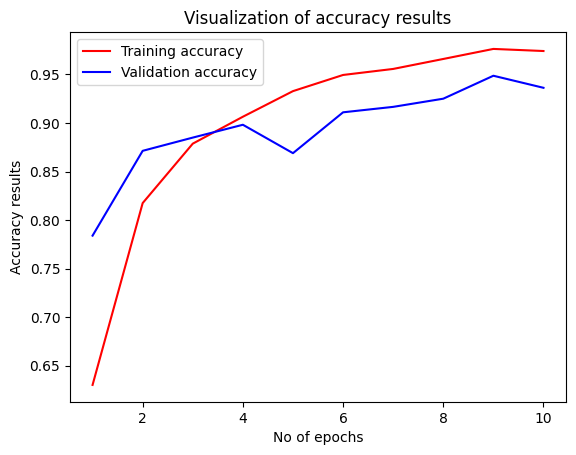

In [29]:
epochs  = [i for i in range(1,11)]
plt.plot(epochs,training_accuracy.history['accuracy'],color = 'red',label = 'Training accuracy')
plt.plot(epochs,training_accuracy.history['val_accuracy'],color = 'blue',label = 'Validation accuracy')
plt.xlabel("No of epochs")
plt.ylabel("Accuracy results")
plt.title("Visualization of accuracy results")
plt.legend()
plt.show()

### SOME OTHER METRICS FOR MODEL EVALUATION

In [30]:
class_name = validation_set.class_names

In [31]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'Val',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=1,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 2495 files belonging to 6 classes.


In [41]:
y_pred = model.predict(test_set)
predicted_categories = tf.argmax(y_pred, axis=1)

2495/2495 [==============================] - 13s 5ms/step


In [42]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = tf.argmax(true_categories, axis=1)

In [34]:
Y_true

<tf.Tensor: shape=(2495,), dtype=int64, numpy=array([0, 0, 0, ..., 5, 5, 5], dtype=int64)>

In [43]:
predicted_categories

<tf.Tensor: shape=(2495,), dtype=int64, numpy=array([0, 0, 0, ..., 5, 5, 5], dtype=int64)>

In [44]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(Y_true,predicted_categories)

In [45]:
print(classification_report(Y_true,predicted_categories))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95       382
           1       0.97      0.78      0.86       432
           2       1.00      0.99      0.99       432
           3       0.82      0.99      0.90       416
           4       0.95      0.92      0.94       392
           5       0.99      0.95      0.97       441

    accuracy                           0.94      2495
   macro avg       0.94      0.94      0.94      2495
weighted avg       0.94      0.94      0.94      2495



In [46]:
print (cm)

[[379   1   0   2   0   0]
 [ 13 335   0  67  14   3]
 [  0   0 429   1   2   0]
 [  0   3   1 411   1   0]
 [ 13   4   1  12 362   0]
 [ 11   1   0   8   1 420]]


In [2]:
plt.figure(figsize=(40, 40))
sns.heatmap(cm,annot=True,annot_kws={"size": 10})

plt.xlabel('Predicted Class',fontsize = 20)
plt.ylabel('Actual Class',fontsize = 20)
plt.title('Plant Disease Prediction Confusion Matrix',fontsize = 25)
plt.show()

NameError: name 'plt' is not defined